In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR

In [23]:
try:
    df = pd.read_csv("Battery_RUL.csv")
    print("Dataset Loaded Successfully")
except Exception as e:
    print("Error loading dataset:", e)

print("\nDataset Shape:", df.shape)
df.head()

Dataset Loaded Successfully

Dataset Shape: (15064, 9)


,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107


In [24]:
# Clean column names to safe python format
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("(", "")
    .str.replace(")", "")
    .str.replace("-", "_")
    .str.replace(".", "")
)

print("Cleaned Columns:")
print(df.columns)

Cleaned Columns:
Index(['Cycle_Index', 'Discharge_Time_s', 'Decrement_36_34V_s',
       'Max_Voltage_Dischar_V', 'Min_Voltage_Charg_V', 'Time_at_415V_s',
       'Time_constant_current_s', 'Charging_time_s', 'RUL'],
      dtype='object')


In [25]:
print("\nDataset Info\n")
print(df.info())

print("\nMissing Values\n")
print(df.isnull().sum())

print("\nStatistical Summary\n")
df.describe()


Dataset Info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15064 entries, 0 to 15063
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cycle_Index              15064 non-null  float64
 1   Discharge_Time_s         15064 non-null  float64
 2   Decrement_36_34V_s       15064 non-null  float64
 3   Max_Voltage_Dischar_V    15064 non-null  float64
 4   Min_Voltage_Charg_V      15064 non-null  float64
 5   Time_at_415V_s           15064 non-null  float64
 6   Time_constant_current_s  15064 non-null  float64
 7   Charging_time_s          15064 non-null  float64
 8   RUL                      15064 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 1.0 MB
None

Missing Values

Cycle_Index                0
Discharge_Time_s           0
Decrement_36_34V_s         0
Max_Voltage_Dischar_V      0
Min_Voltage_Charg_V        0
Time_at_415V_s             0
Time_constant_current_s    0
Charging

,Cycle_Index,Discharge_Time_s,Decrement_36_34V_s,Max_Voltage_Dischar_V,Min_Voltage_Charg_V,Time_at_415V_s,Time_constant_current_s,Charging_time_s,RUL
count,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000,15064.000000
mean,556.155005,4581.273960,1239.784672,3.908176,3.577904,3768.336171,5461.266970,10066.496204,554.194172
std,322.378480,33144.012077,15039.589269,0.091003,0.123695,9129.552477,25155.845202,26415.354121,322.434514
min,1.000000,8.690000,-397645.908000,3.043000,3.022000,-113.584000,5.980000,5.980000,0.000000
25%,271.000000,1169.310000,319.600000,3.846000,3.488000,1828.884179,2564.310000,7841.922500,277.000000
50%,560.000000,1557.250000,439.239471,3.906000,3.574000,2930.203500,3824.260000,8320.415000,551.000000
75%,833.000000,1908.000000,600.000000,3.972000,3.663000,4088.326500,5012.350000,8763.282500,839.000000
max,1134.000000,958320.370000,406703.768000,4.363000,4.379000,245101.117000,880728.100000,880728.100000,1133.000000


In [26]:
# Fill missing numeric values if any
df = df.fillna(df.median(numeric_only=True))

# Remove duplicates
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (15064, 9)


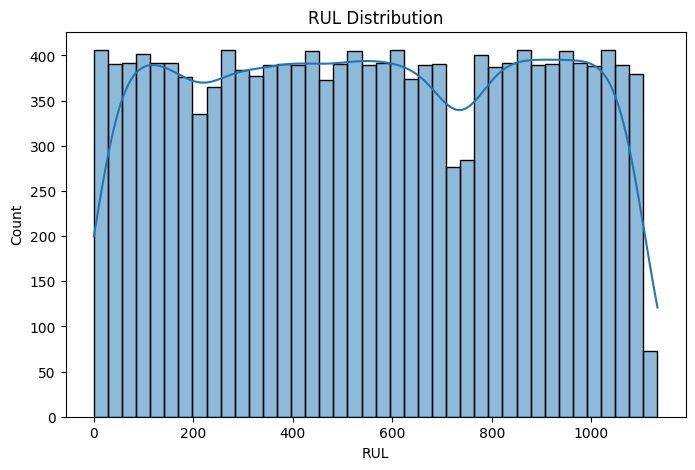

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df["RUL"], bins=40, kde=True)
plt.title("RUL Distribution")
plt.show()

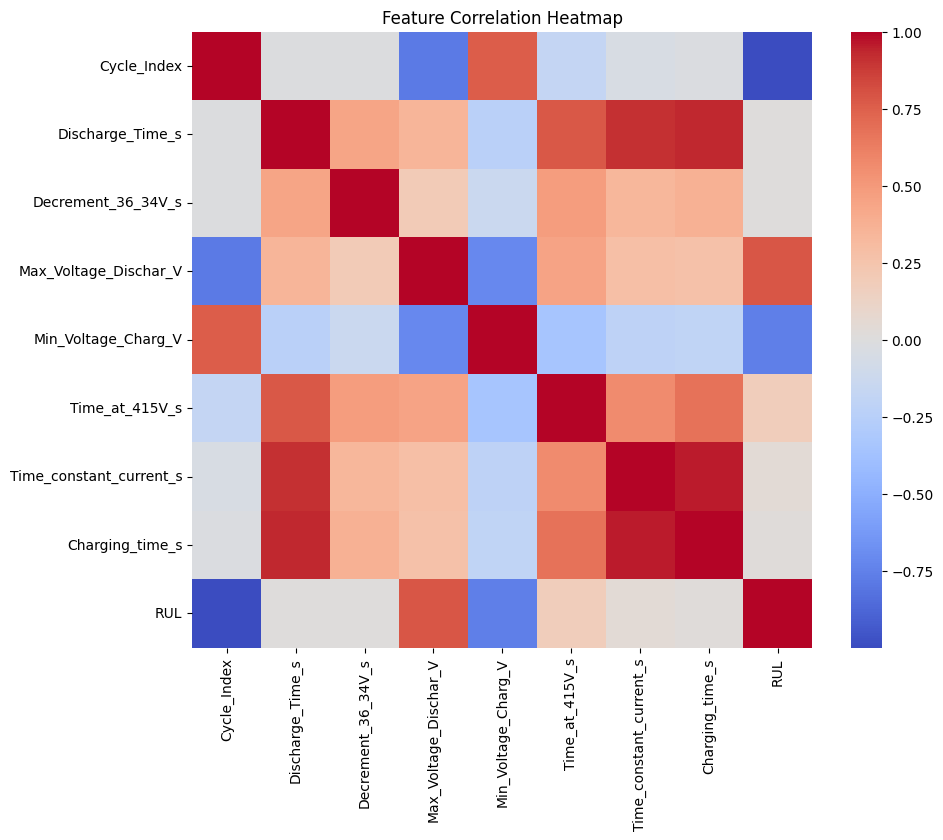

In [28]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [29]:
target = "RUL"

X = df.drop(columns=[target])
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (15064, 8)
Target Shape: (15064,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (12051, 8)
Test size: (3013, 8)


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "SVR": SVR()
}

In [33]:
results = []

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])

results_df.sort_values(by="R2", ascending=False)

,Model,MAE,RMSE,R2
3,Extra Trees,1.783090,3.341843,0.999892
1,Random Forest,2.126170,3.793531,0.999861
0,Linear Regression,4.644132,7.385328,0.999473
2,Gradient Boosting,4.985453,7.580654,0.999445
4,SVR,21.299727,59.190844,0.966177


In [34]:
rf = RandomForestRegressor(random_state=42)

scores = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.99984361 0.99980225 0.99985689 0.99985025 0.99982345]
Average CV Score: 0.9998352905116101


In [35]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [36]:
preds = best_model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Best Model Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Model Performance
MAE: 2.099897771048326
RMSE: 3.767251815016363
R2 Score: 0.9998629907564001


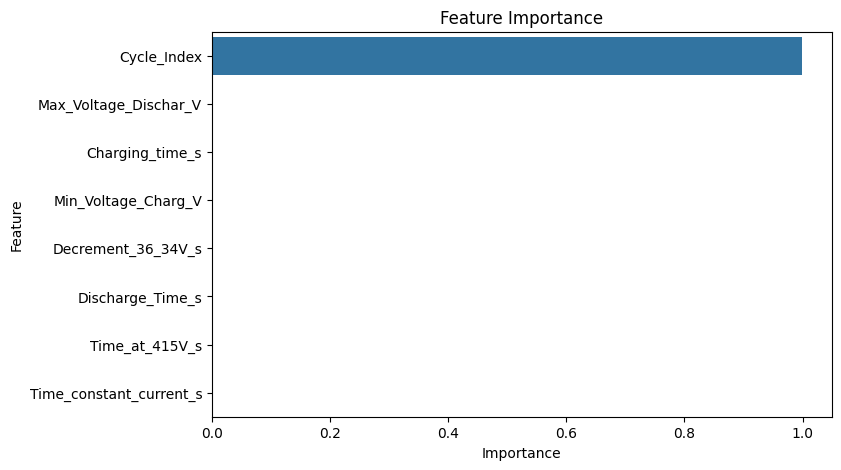

In [37]:
importances = best_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=feat_imp, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

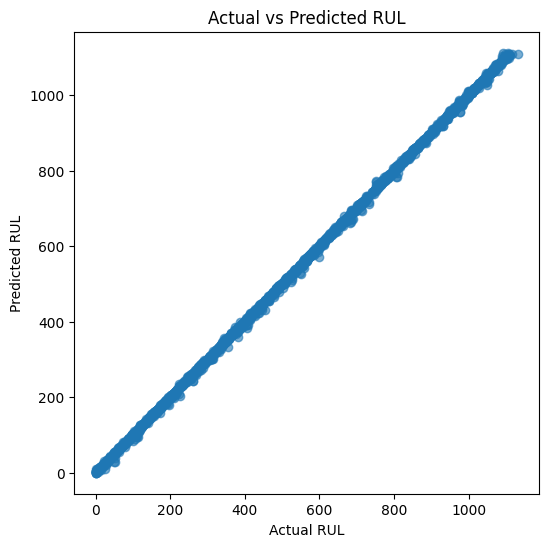

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.6)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")
plt.show()

In [39]:
joblib.dump(best_model, "battery_rul_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

Model and scaler saved successfully.


In [40]:
model = joblib.load("battery_rul_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")

sample = X_test.iloc[0:1]

sample_scaled = scaler_loaded.transform(sample)

prediction = model.predict(sample_scaled)

print("Sample Prediction:", prediction[0])

Sample Prediction: 1043.455
